In [1]:
from config import DEVELOPMENT_SET, INPUT_JSON, OUTPUT_EXAMPLE
from utils import * 

### **Loading the image list and the optional ground truth**

Loads the image list from example_json and prints the first 5 image paths. Output example json file contains only 1 example of the desired output for this task.
- ***load_input_paths(input_json)***
- ***load_output_example(output_json)***

In [2]:
image_paths = load_input_paths(input_json=INPUT_JSON)
print("Number of images from input.json:", len(image_paths))
print("First 5:")
for p in image_paths[:5]:
    print(" -", p)

gt_example = None
if OUTPUT_EXAMPLE.exists():
    gt_example = load_output_example(output_json=OUTPUT_EXAMPLE)
    print("\nLoaded output example with", len(gt_example), "records")
else:
    print("\nNo output example found")

Number of images from input.json: 50
First 5:
 - /home/rodrigobatista/PycharmProjects/4ano/2semestre/8_BallPool_ComputerVision/development_set/106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg
 - /home/rodrigobatista/PycharmProjects/4ano/2semestre/8_BallPool_ComputerVision/development_set/10a_png.rf.bdc9984ba169594ea32b012098ad10dd.jpg
 - /home/rodrigobatista/PycharmProjects/4ano/2semestre/8_BallPool_ComputerVision/development_set/110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg
 - /home/rodrigobatista/PycharmProjects/4ano/2semestre/8_BallPool_ComputerVision/development_set/114_png.rf.98b2144c25b9f48816abd7edb00f365c.jpg
 - /home/rodrigobatista/PycharmProjects/4ano/2semestre/8_BallPool_ComputerVision/development_set/115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg

Loaded output example with 1 records


### Dataset Inspection

Run this several times on different images. Change `IDX` freely.

In [3]:
IDX = 15

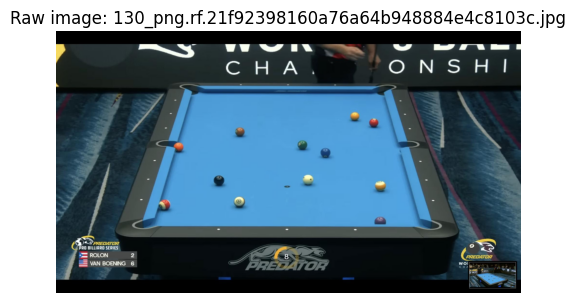

In [4]:
img_path = image_paths[IDX]
img_rgb = imread_rgb(img_path)

show(img_rgb, title=f"Raw image: {img_path.name}", figsize=(6, 4))

### **Color spaces**

This helps decide whether HSV alone is enough, or whether LAB / grayscale also help.

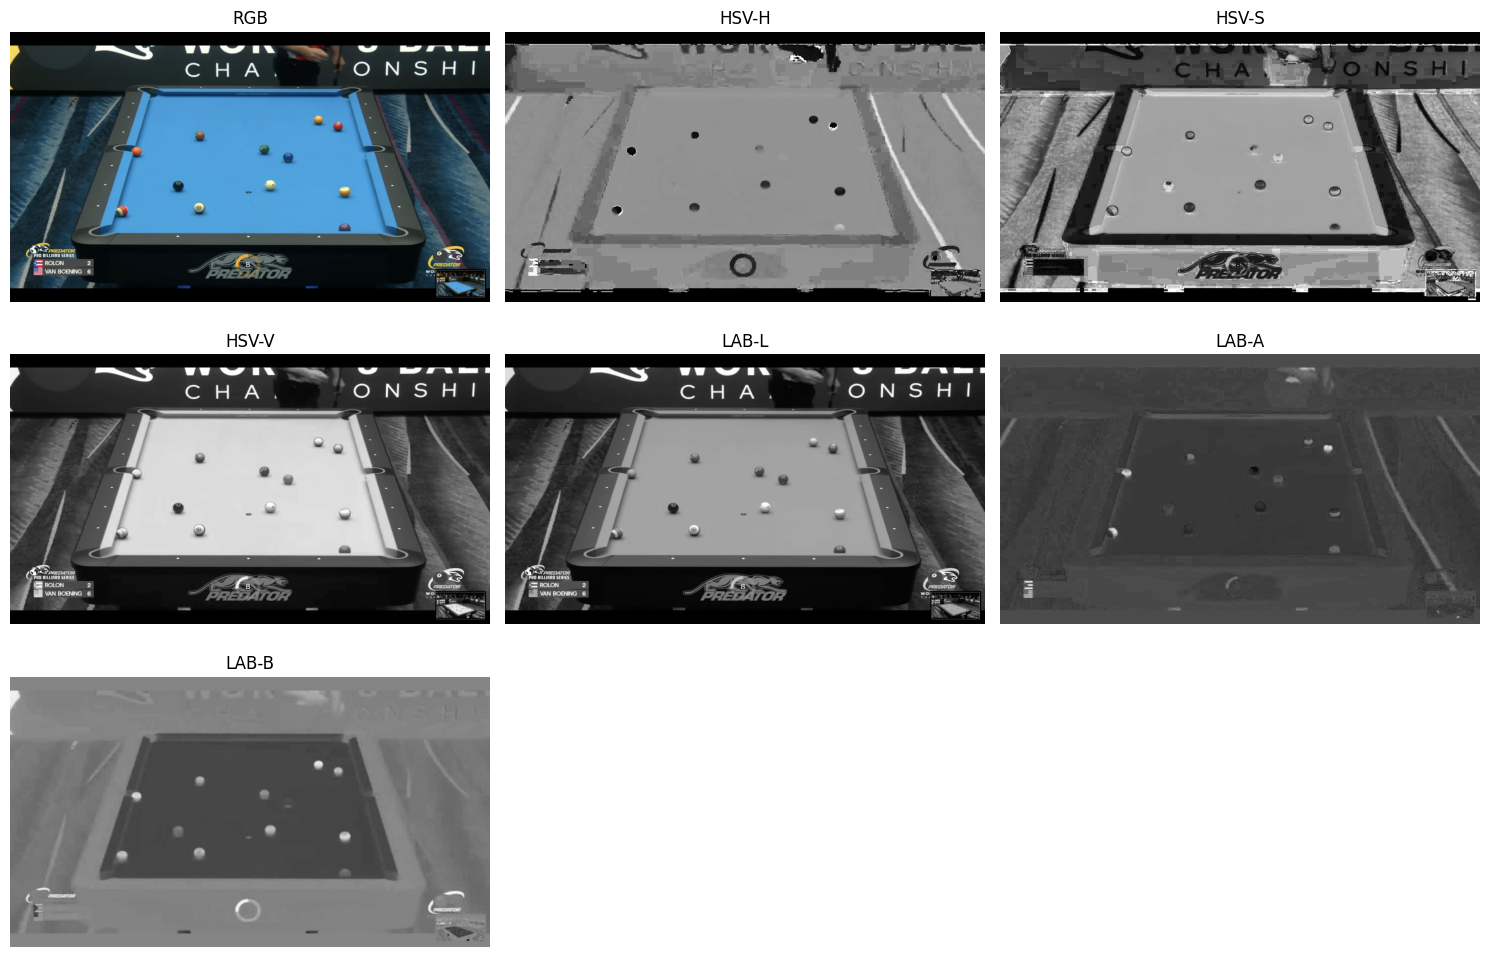

In [5]:
bgr = imread_bgr(img_path)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)

images = [rgb,
          hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2],
          lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]]

titles = ["RGB", "HSV-H", "HSV-S", "HSV-V", "LAB-L", "LAB-A", "LAB-B"]
show_many(images, titles=titles, cols=3, figsize=(15, 10))


From the visualization of RGB, HSV, and LAB channels, we can extract the following insights:

- Hue (HSV-H) is relatively uniform for the table but unstable in low-saturation regions (shadows, reflections), making it unreliable as a standalone feature.
- Saturation (HSV-S) clearly separates the table from the background.
The table cloth has consistently high saturation, while surrounding elements (walls, players, text) have lower saturation.

    → This makes HSV-S a strong candidate for table segmentation.


- Value (HSV-V) and LAB-L (lightness) mainly encode brightness and do not provide strong discrimination between table and background.

- LAB-B channel provides a very strong contrast between the table and the balls.
The table appears homogeneous, while the balls stand out clearly as distinct regions.

    → This makes LAB-B particularly useful for ball detection.
    
For ball classification, HSV remains the most appropriate space, since hue directly encodes color information.

## **Table Detection**

**Goal:** *Obtain a reliable top-view transformation*

**Methodology:**

- ***Mask*** — segment the table region from the image
- ***Contour*** — extract the main shape corresponding to the table
- ***Corners*** — estimate the four corner points of that shape
- ***Warp*** — apply a perspective transform to obtain a normalized top-view

### **Mask**

Candidate methods for table detection: 

1. Fixed HSV thresholding (baseline)
2. Saturation-based segmentation
3. Adaptive color estimation from the image

1. **Fixed HSV thresholding**

In [6]:
def detect_table_hsv_basic(bgr, blue_lower=(85, 40, 40), blue_upper=(130, 255, 255), 
                           green_lower=(35, 30, 30), green_upper=(90, 255, 255)):
    
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    mask_blue = cv2.inRange(hsv, np.array(blue_lower), np.array(blue_upper))
    mask_green = cv2.inRange(hsv, np.array(green_lower), np.array(green_upper))
    mask = cv2.bitwise_or(mask_blue, mask_green)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask


2. **Saturation/value thresholding**

In [7]:
def detect_table_satval(bgr, sat_thr=40, val_thr=40):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    mask = ((s > sat_thr) & (v > val_thr)).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask

3. **Saturation/value thresholding**

In [8]:
def detect_table_mask_adaptive(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]

    cx1, cy1 = int(w * 0.35), int(h * 0.35)
    cx2, cy2 = int(w * 0.65), int(h * 0.65)
    center = hsv[cy1:cy2, cx1:cx2]

    h_vals = center[:, :, 0].reshape(-1)
    s_vals = center[:, :, 1].reshape(-1)
    v_vals = center[:, :, 2].reshape(-1)

    valid = (s_vals > 50) & (v_vals > 50)
    if valid.sum() < 50:
        return None

    h_med = int(np.median(h_vals[valid]))
    low = max(0, h_med - 18)
    high = min(179, h_med + 18)

    mask = cv2.inRange(hsv, np.array([low, 70, 70]), np.array([high, 255, 255]))

    # remove likely noise bands
    mask[:int(0.2 * h), :] = 0
    mask[int(0.9 * h):, :] = 0

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask

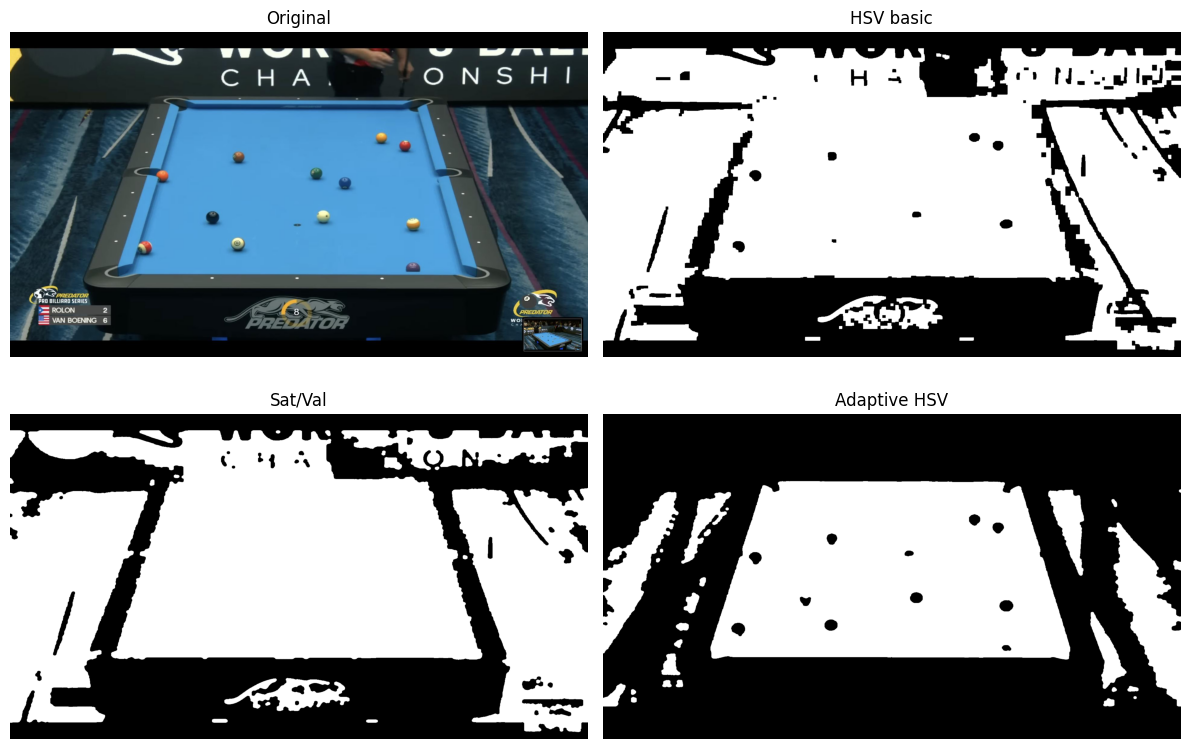

In [9]:
mask_hsv = detect_table_hsv_basic(bgr)
mask_satval = detect_table_satval(bgr)
mask_adaptive = detect_table_mask_adaptive(bgr)

show_many(
    [rgb, mask_hsv, mask_satval, mask_adaptive],
    titles=["Original", "HSV basic", "Sat/Val", "Adaptive HSV"],
    cols=2,
    figsize=(12, 8)
)

### **Contour**

- Mask with noise --> Necessary to extract the main component and remove the noise

In [10]:
def extract_main_table_component(mask):
    ''' 
    Given a mask, extract the largest connected component closest to the image center
    '''
    if mask is None:
        return None

    h, w = mask.shape[:2]
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    if num_labels <= 1:
        return None

    center_pt = np.array([w / 2, h / 2])
    best_label = None
    best_dist = float("inf")

    for i in range(1, num_labels):
        c = centroids[i]
        dist = np.linalg.norm(c - center_pt)
        if dist < best_dist:
            best_dist = dist
            best_label = i

    component_mask = np.uint8(labels == best_label) * 255
    return component_mask

In [11]:
def extract_table_contour(component_mask):
    '''
    Receives a binary mask of the main component and extracts its contour
    '''
    if component_mask is None:
        return None

    contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    contour = max(contours, key=cv2.contourArea)
    contour = cv2.convexHull(contour)
    return contour

#### Mask + Contour

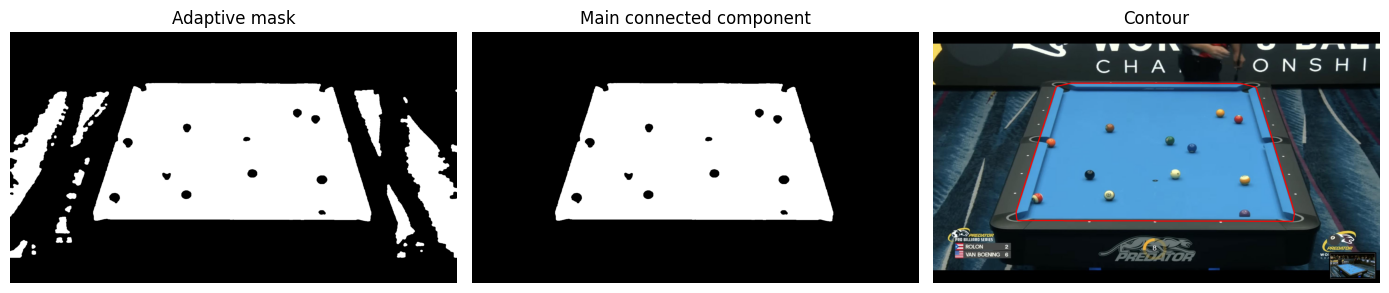

In [12]:
mask = detect_table_mask_adaptive(bgr)
component_mask = extract_main_table_component(mask)
contour = extract_table_contour(component_mask)

rgb_contour = rgb.copy()
if contour is not None:
    cv2.drawContours(rgb_contour, [contour], -1, (255, 0, 0), 3)

show_many(
    [mask, component_mask, rgb_contour],
    titles=["Adaptive mask", "Main connected component", "Contour"],
    cols=3,
    figsize=(14, 5)
)

### **Corners**

In [13]:
def order_points(pts):
    '''
    Orders the argument points in the following order, by summing and differencing the coordinates:
        - Top-left (tl): point with the smallest sum of coordinates (x + y)
        - Bottom-right (br): point with the largest sum of coordinates (x + y)
        - Top-right (tr): point with the smallest difference of coordinates (y - x)
        - Bottom-left (bl): point with the largest difference of coordinates (y - x)
    Returns the ordered points as a numpy array of shape (4, 2) --> [[tl_x, tl_y], [tr_x, tr_y], [br_x, br_y], [bl_x, bl_y]]
    '''
    pts = np.asarray(pts, dtype=np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1)
    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(d)] 
    bl = pts[np.argmax(d)] 
    return np.array([tl, tr, br, bl], dtype=np.float32)


def polygon_area(pts):
    pts = np.asarray(pts, dtype=np.float32)
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

In [14]:
def contour_to_corners_refined(contour):
    if contour is None:
        return None

    peri = cv2.arcLength(contour, True)
    print("Contour perimeter:", peri)

    approx = None
    for eps in [0.01, 0.02, 0.03]:
        approx_candidate = cv2.approxPolyDP(contour, eps * peri, True)
        if len(approx_candidate) == 4:
            approx = approx_candidate
            break

    if approx is not None:
        corners = approx.reshape(4, 2)
    else:
        rect = cv2.minAreaRect(contour)
        corners = cv2.boxPoints(rect)

    corners = order_points(corners)

    if polygon_area(corners) < 1000:
        return None

    return corners

Contour perimeter: 3243.62823843956


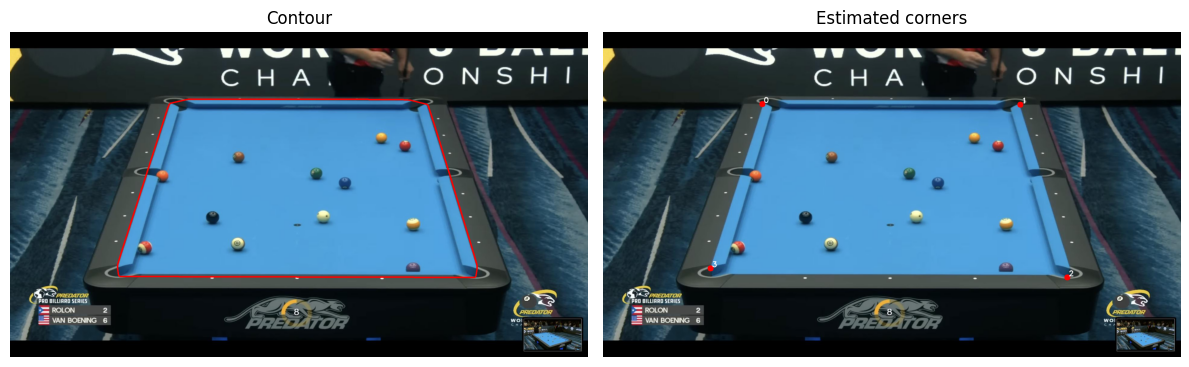

In [15]:
corners = contour_to_corners_refined(contour)
rgb_corners = rgb.copy()
if corners is not None:
    for i, (x, y) in enumerate(corners.astype(int)):
        cv2.circle(rgb_corners, (x, y), 10, (255, 0, 0), -1)
        cv2.putText(rgb_corners, str(i), (x + 5, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

show_many(
    [rgb_contour, rgb_corners],
    titles=["Contour", "Estimated corners"],
    cols=2,
    figsize=(12, 5)
)

### **Warp**

- Applied a perspective warp (homography) to obtain a top-down view of the pool table

- Perspective images can produce ambiguous top views, where length and width may be swapped depending on camera orientation.

- Handling this ambiguity is out of scope for the project, so we adopted a generalized assumption -> CAN DO YOLO!!!! .

- Enforced a 2:1 aspect ratio (width / height) based on the longest side.

In [16]:
def expand_corners(corners, expand_px=20):
    """Push corners outward so rails/balls at edges aren't clipped."""
    cx = np.mean(corners[:, 0])
    cy = np.mean(corners[:, 1])
    expanded = []
    for (x, y) in corners:
        dx = x - cx
        dy = y - cy
        norm = np.sqrt(dx**2 + dy**2) + 1e-6
        expanded.append([x + expand_px * dx / norm,
                         y + expand_px * dy / norm])
    return np.array(expanded, dtype=np.float32)

def warp_table(bgr, corners):
    pts = order_points(corners)
    pts_expanded = expand_corners(pts, expand_px=25)  # checked - Necessary ? 

    (tl, tr, br, bl) = pts_expanded 

    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)

    maxWidth = int((widthA + widthB) / 2)

    # enforce pool table aspect ratio (2:1)
    aspect_ratio = 2.0 # width / height
    maxHeight = int(maxWidth * aspect_ratio)
 
    scale = 2.0
    maxWidth = int(maxWidth * scale)
    maxHeight = int(maxHeight * scale)

    dst = np.array([[0,0],[maxWidth-1,0],[maxWidth-1,maxHeight-1],[0,maxHeight-1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(pts_expanded, dst)
    warped = cv2.warpPerspective(bgr, M, (maxWidth, maxHeight), flags=cv2.INTER_CUBIC)
    return warped, M

Estimated corners:
 [[ 529.  239.]
 [1386.  241.]
 [1542.  815.]
 [ 357.  785.]]


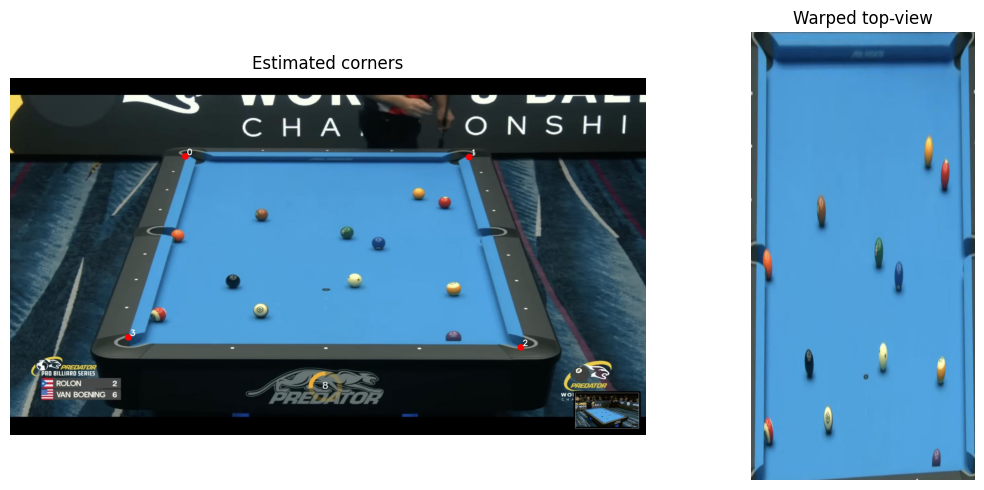

In [17]:
if corners is not None:
    print("Estimated corners:\n", corners)
    warped_bgr, M = warp_table(bgr, corners)
    warped_rgb = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB)

    show_many(
        [rgb_corners, warped_rgb],
        titles=["Estimated corners", "Warped top-view"],
        cols=2,
        figsize=(12, 5)
    )
else:
    print("Warp not computed because corners were not found.")

### **Ball Detection**



In [18]:
def get_ball_mask_original(bgr):
    """
    Applies the ball detection mask to the original (non-warped) image,
    restricting the analysis to the table playing surface.

    Instead of warping the image, we detect the table contour and use it
    as a validity mask — anything outside the table polygon is ignored.
    This avoids perspective distortion artifacts introduced by warping.

    Args:
        bgr: original BGR image

    Returns:
        ball_mask: binary mask (uint8, 0 or 255) in original image space,
                   or None if table detection failed
    """
    h, w = bgr.shape[:2]

    # --- Step 1: Detect table contour in original image ---
    mask = detect_table_mask_adaptive(bgr)
    if mask is None:
        return None

    component = extract_main_table_component(mask)
    if component is None:
        return None

    contour = extract_table_contour(component)
    if contour is None:
        return None

    # --- Step 2: Build validity mask from table contour ---
    # Fill the table polygon — everything outside is excluded
    valid_region = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(valid_region, [contour], 255)

    # Erode slightly inward to exclude rails and pocket edges
    erode_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    valid_region = cv2.erode(valid_region, erode_k, iterations=1)

    # --- Step 3: Estimate cloth colour from center of valid region ---
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    cx1, cy1 = int(w * 0.3), int(h * 0.3)
    cx2, cy2 = int(w * 0.7), int(h * 0.7)
    center = hsv[cy1:cy2, cx1:cx2]

    h_vals = center[:, :, 0].reshape(-1)
    s_vals = center[:, :, 1].reshape(-1)
    v_vals = center[:, :, 2].reshape(-1)

    valid = (s_vals > 40) & (v_vals > 40)
    if valid.sum() < 50:
        return None

    h_med = int(np.median(h_vals[valid]))
    s_med = int(np.median(s_vals[valid]))
    v_med = int(np.median(v_vals[valid]))

    # --- Step 4: Compute per-pixel deviation from cloth colour ---
    H = hsv[:, :, 0].astype(np.int16)
    S = hsv[:, :, 1].astype(np.int16)
    V = hsv[:, :, 2].astype(np.int16)

    h_diff = np.abs(H - h_med)
    h_diff = np.minimum(h_diff, 180 - h_diff)
    s_diff = np.abs(S - s_med)
    v_diff = np.abs(V - v_med)

    is_cloth = (h_diff < 20) & (s_diff < 35) & (v_diff < 35)

    # --- Step 5: Ball mask = NOT cloth, restricted to table region ---
    ball_mask = (~is_cloth).astype(np.uint8) * 255
    ball_mask = cv2.bitwise_and(ball_mask, valid_region)

    # --- Step 6: Morphological cleanup ---
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    ball_mask = cv2.morphologyEx(ball_mask, cv2.MORPH_OPEN, k)
    ball_mask = cv2.morphologyEx(ball_mask, cv2.MORPH_CLOSE, k)

    return ball_mask

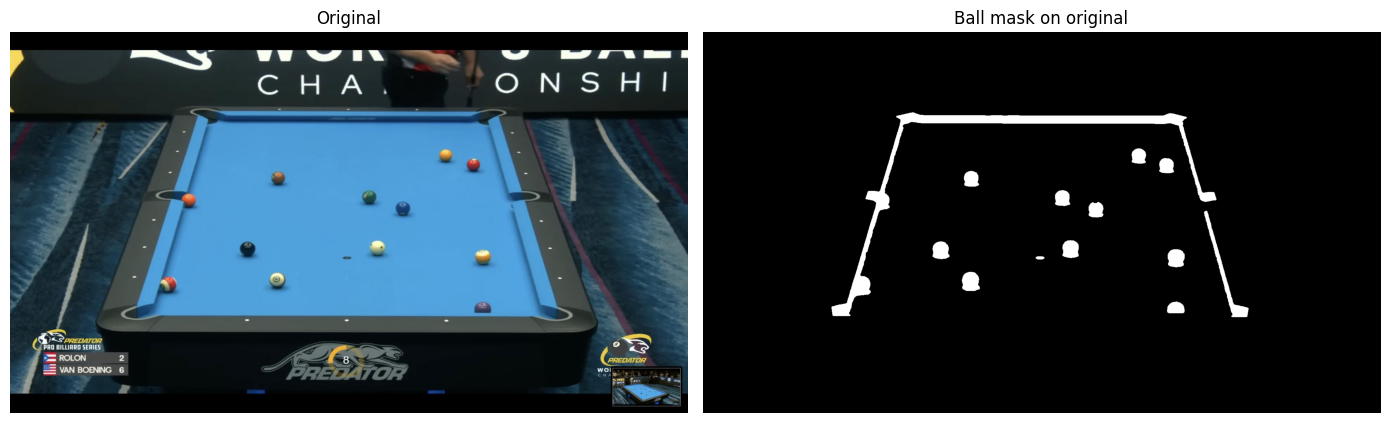

In [19]:
ball_mask_orig = get_ball_mask_original(bgr)

show_many(
    [cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), ball_mask_orig],
    titles=["Original", "Ball mask on original"],
    cols=2,
    figsize=(14, 6)
)

In [20]:
def extract_ball_bboxes_original(ball_mask, bgr):
    """
    Extracts bounding boxes for ball candidates from a binary mask
    computed on the original (non-warped) image.

    Uses connected components to find blobs, then filters by:
      - Area: derived from expected ball radius (~2.5% of the shorter
              image dimension), with tolerance for perspective distortion
      - Aspect ratio: balls are roughly square in the original image
      - Circularity: rejects non-circular blobs (shadows, noise)

    Args:
        ball_mask: binary mask from get_ball_mask_original() (uint8, 0 or 255)
        bgr: original BGR image (used for dimensions)

    Returns:
        List of dicts with keys:
            'cx', 'cy': centroid in pixels
            'x1', 'y1', 'x2', 'y2': bounding box corners
    """
    if ball_mask is None:
        return []

    h, w = bgr.shape[:2]

    # Expected ball radius as ~2.5% of the shorter image dimension.
    # We use the shorter side because in perspective images the table
    # may occupy very different fractions of width vs height.
    expected_r = min(h, w) * 0.025
    min_area = int(np.pi * (expected_r * 0.4) ** 2)  # 40% of expected r
    max_area = int(np.pi * (expected_r * 1.8) ** 2)  # 180% of expected r

    print(f"  Expected radius: {expected_r:.1f}px")
    print(f"  Area filter: [{min_area}, {max_area}]")

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(ball_mask)

    detections = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if not (min_area < area < max_area):
            continue

        bw = stats[i, cv2.CC_STAT_WIDTH]
        bh = stats[i, cv2.CC_STAT_HEIGHT]

        # Reject very elongated blobs (shadows, rails)
        aspect = min(bw, bh) / max(bw, bh) if max(bw, bh) > 0 else 0
        if aspect < 0.35:
            continue

        # Circularity filter — rejects non-circular blobs
        blob = (labels == i).astype(np.uint8) * 255
        cnts, _ = cv2.findContours(blob, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        peri = cv2.arcLength(cnts[0], True)
        if peri == 0:
            continue
        circ = 4 * np.pi * area / (peri * peri)
        if circ < 0.50:
            continue

        cx, cy = centroids[i]
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        detections.append({
            'cx': cx, 'cy': cy,
            'x1': x,        'y1': y,
            'x2': x + bw,   'y2': y + bh
        })

    return detections

  Expected radius: 27.0px
  Area filter: [366, 7420]
Balls detected: 10


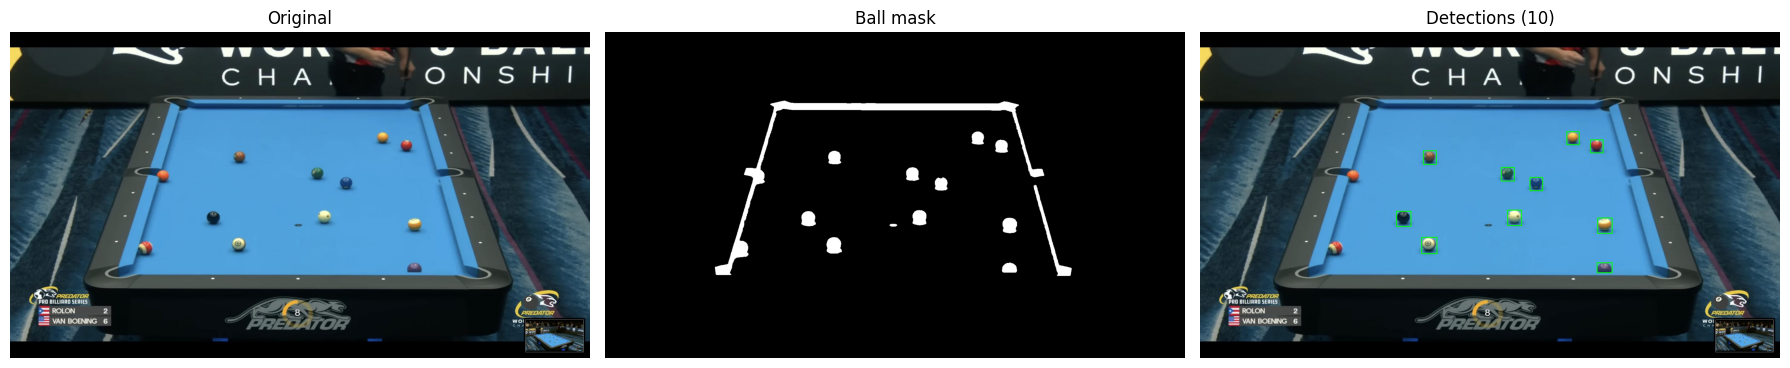

In [21]:
ball_mask_orig = get_ball_mask_original(bgr)
detections = extract_ball_bboxes_original(ball_mask_orig, bgr)

print(f"Balls detected: {len(detections)}")

# Draw bounding boxes on original image
vis = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy()
for det in detections:
    cv2.rectangle(vis,
                  (det['x1'], det['y1']),
                  (det['x2'], det['y2']),
                  (0, 255, 0), 2)

show_many(
    [cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), ball_mask_orig, vis],
    titles=["Original", "Ball mask", f"Detections ({len(detections)})"],
    cols=3,
    figsize=(18, 6)
)

### **Trying to solve the problem of two balls near each other**

In [22]:
def extract_ball_bboxes_watershed(ball_mask, bgr):
    """
    Extracts bounding boxes for ball candidates using the Watershed algorithm
    to separate touching balls that would otherwise be detected as a single blob.

    Pipeline:
      1. Distance transform: each white pixel gets a value proportional to its
         distance to the nearest background pixel. Ball centers = local peaks.
      2. Threshold the distance map to find confident foreground seeds (peaks).
         Each connected region of peaks = one ball center.
      3. Build the marker map for Watershed:
           - Seeds (peaks) = positive labels (one per ball)
           - Confirmed background = label 0
           - Unknown region (between seeds and background) = -1
      4. Run Watershed — it expands each seed until boundaries are found.
      5. Extract bounding boxes from each labeled region.

    Args:
        ball_mask: binary mask from get_ball_mask_original() (uint8, 0 or 255)
        bgr: original BGR image

    Returns:
        List of dicts with keys:
            'cx', 'cy': centroid in pixels
            'x1', 'y1', 'x2', 'y2': bounding box corners
    """
    if ball_mask is None:
        return []

    h, w = bgr.shape[:2]

    # --- Step 1: Distance transform ---
    # Each white pixel gets a value = distance to nearest black pixel.
    # Ball centers will be local maxima in this map.
    dist = cv2.distanceTransform(ball_mask, cv2.DIST_L2, 5)
    dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)

    # --- Step 2: Threshold to find peak regions (seeds) ---
    # Only keep pixels that are at least 50% of the maximum distance value.
    # These are the confident centers of balls.
    # Lower = more seeds (may split one ball into two)
    # Higher = fewer seeds (may miss touching balls)
    _, seeds = cv2.threshold(dist_norm, 0.6, 1.0, cv2.THRESH_BINARY)
    seeds = seeds.astype(np.uint8)

    # --- Step 3: Build marker map ---
    # Label each seed region with a unique integer (one per ball candidate)
    num_labels, markers = cv2.connectedComponents(seeds)

    # Add 1 to all labels so that background (0) becomes 1,
    # and seed regions become 2, 3, 4, ...
    # This is required by cv2.watershed which uses 0 as "unknown"
    markers = markers + 1

    # Mark the unknown region (dilated mask minus seeds) as 0
    # These are the pixels Watershed will decide how to assign
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    dilated = cv2.dilate(ball_mask, kernel, iterations=3)
    unknown = cv2.subtract(dilated, seeds * 255)
    markers[unknown == 255] = 0

    # --- Step 4: Run Watershed ---
    # Watershed needs a 3-channel BGR image
    markers = cv2.watershed(bgr, markers)
    # After watershed: -1 = boundary, 1 = background, 2+ = ball regions

    # --- Step 5: Extract bounding boxes from each labeled region ---
    expected_r = min(h, w) * 0.025
    min_area = int(np.pi * (expected_r * 0.4) ** 2)
    max_area = int(np.pi * (expected_r * 1.8) ** 2)

    detections = []
    for label in range(2, num_labels + 1):  # skip 1 (background)
        region = (markers == label).astype(np.uint8) * 255

        area = cv2.countNonZero(region)
        if not (min_area < area < max_area):
            continue

        # Bounding box
        contours_r, _ = cv2.findContours(region, cv2.RETR_EXTERNAL,
                                          cv2.CHAIN_APPROX_SIMPLE)
        if not contours_r:
            continue

        x, y, bw, bh = cv2.boundingRect(contours_r[0])

        # Reject very elongated regions
        aspect = min(bw, bh) / max(bw, bh) if max(bw, bh) > 0 else 0
        if aspect < 0.35:
            continue

        # Circularity
        peri = cv2.arcLength(contours_r[0], True)
        if peri == 0:
            continue
        circ = 4 * np.pi * area / (peri * peri)
        if circ < 0.45:
            continue

        cx = x + bw / 2
        cy = y + bh / 2
        detections.append({
            'cx': cx, 'cy': cy,
            'x1': x,      'y1': y,
            'x2': x + bw, 'y2': y + bh
        })

    return detections

Balls detected: 12


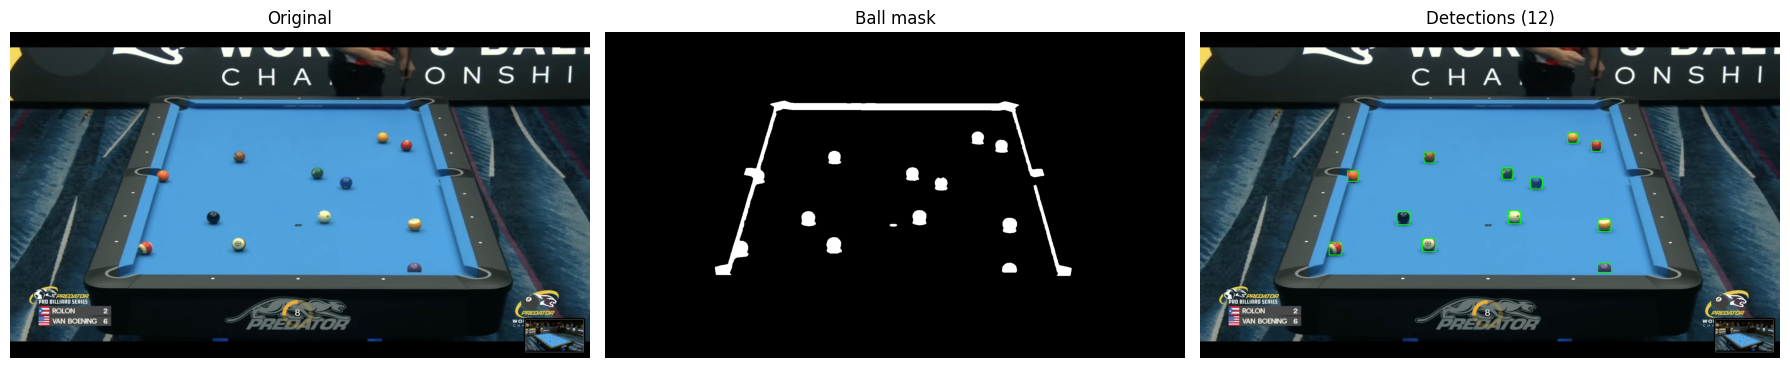

In [23]:
ball_mask_orig = get_ball_mask_original(bgr)
detections = extract_ball_bboxes_watershed(ball_mask_orig, bgr)

print(f"Balls detected: {len(detections)}")

# Draw bounding boxes
vis = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy()
for det in detections:
    cv2.rectangle(vis,
                  (det['x1'], det['y1']),
                  (det['x2'], det['y2']),
                  (0, 255, 0), 2)

show_many(
    [cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), ball_mask_orig, vis],
    titles=["Original", "Ball mask", f"Detections ({len(detections)})"],
    cols=3,
    figsize=(18, 6)
)

### **Classification of balls**

In [24]:
# Ball colour definitions in HSV space.
# Each entry: (hue_min, hue_max, sat_min, val_min)
# These ranges were defined based on standard pool ball colours.
BALL_COLOURS = {
    1:  (18,  32,  130, 130),   # yellow solid  — high sat/val, mid hue
    2:  (95, 115,  100,  80),   # blue solid    — H ~100-110 from data
    3:  (0,   7,   120,  80),   # red solid     — low hue only
    4:  (100, 120,  80,  60),   # purple solid  — H ~105-108 from data
    5:  (8,   18,  120, 120),   # orange solid  — H ~8-18, high sat/val
    6:  (35,  95,   80,  50),   # green solid   — extended to H=95
    7:  (18,  32,   60, 60),    # brown solid   — lower sat than orange
    8:  (0,  180,   0,   0),    # black         — matched by low value
}

# Stripe balls have the same hue as their solid counterpart
STRIPE_MAP = {
    9:  1,   # yellow stripe
    10: 2,   # blue stripe
    11: 3,   # red stripe
    12: 4,   # purple stripe
    13: 5,   # orange stripe
    14: 6,   # green stripe
    15: 7,   # brown stripe
}


def is_white_pixel(hsv_pixel, sat_thr=40, val_thr=180):
    """
    Returns True if a pixel is considered white/light.
    White pixels have low saturation and high value.

    Args:
        hsv_pixel: array of (H, S, V) values
        sat_thr: maximum saturation to be considered white
        val_thr: minimum value (brightness) to be considered white
    """
    return hsv_pixel[1] < sat_thr and hsv_pixel[2] > val_thr


def get_white_fraction(ball_region_hsv, ball_region_mask):
    """
    Computes the fraction of ball pixels that are white/light.
    Used to distinguish: cue ball (>70%), stripes (>25%), solids (<25%).

    Args:
        ball_region_hsv: HSV crop of the bounding box
        ball_region_mask: binary mask of the ball pixels within the crop

    Returns:
        Float between 0 and 1.
    """
    ball_pixels = ball_region_hsv[ball_region_mask > 0]
    if len(ball_pixels) == 0:
        return 0.0

    white_pixels = np.sum(
        (ball_pixels[:, 1] < 90) & (ball_pixels[:, 2] > 140)
    )
    return white_pixels / len(ball_pixels)


def get_dominant_colour(ball_region_hsv, ball_region_mask):
    """
    Returns the median hue and saturation of the non-white ball pixels.
    White pixels (reflexos, stripes) are excluded to get the true ball colour.

    Args:
        ball_region_hsv: HSV crop of the bounding box
        ball_region_mask: binary mask of the ball pixels within the crop

    Returns:
        (median_hue, median_sat, median_val) or None if no valid pixels
    """
    ball_pixels = ball_region_hsv[ball_region_mask > 0]
    if len(ball_pixels) == 0:
        return None

    # Exclude white pixels (reflexos, stripe white band)
    non_white = ball_pixels[
        ~((ball_pixels[:, 1] < 40) & (ball_pixels[:, 2] > 180))
    ]
    if len(non_white) == 0:
        return None

    median_h = int(np.median(non_white[:, 0]))
    median_s = int(np.median(non_white[:, 1]))
    median_v = int(np.median(non_white[:, 2]))
    return (median_h, median_s, median_v)


def match_colour_to_ball(median_hsv):
    """
    Matches a median HSV colour to the closest solid ball number (1-8).
    The black ball (8) is matched by low value rather than hue.

    Args:
        median_hsv: (h, s, v) tuple from get_dominant_colour()

    Returns:
        Ball number (1-8), or None if no match found.
    """
    if median_hsv is None:
        return None

    h, s, v = median_hsv

    # Black ball: very low value regardless of hue
    if v < 80:
        return 8

    for ball_num, (h_min, h_max, s_min, v_min) in BALL_COLOURS.items():
        if ball_num == 8:
            continue
        if h_min <= h <= h_max and s >= s_min and v >= v_min:
            return ball_num

    return None


def classify_ball(det, bgr, ball_mask):
    """
    Classifies a detected ball by analysing its colour and white fraction.

    Steps:
      1. Extract the bounding box region from the image and mask
      2. Compute white fraction to distinguish cue ball / stripe / solid
      3. Get dominant colour of non-white pixels
      4. Match colour to ball number

    Args:
        det: detection dict with 'x1', 'y1', 'x2', 'y2'
        bgr: original BGR image
        ball_mask: binary mask from get_ball_mask_original()

    Returns:
        Ball number (0-15), or None if classification failed.
    """
    x1, y1, x2, y2 = det['x1'], det['y1'], det['x2'], det['y2']

    # Clamp to image bounds
    ih, iw = bgr.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(iw, x2), min(ih, y2)

    if x2 <= x1 or y2 <= y1:
        return None

    # Extract crops
    bgr_crop = bgr[y1:y2, x1:x2]
    mask_crop = ball_mask[y1:y2, x1:x2]
    hsv_crop = cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2HSV)

    # Step 1: white fraction
    white_frac = get_white_fraction(hsv_crop, mask_crop)

    # Step 2: cue ball detection
    if white_frac > 0.65:
        return 0  # cue ball (white)

    # Step 3: dominant colour
    median_hsv = get_dominant_colour(hsv_crop, mask_crop)
    solid_num = match_colour_to_ball(median_hsv)

    if solid_num is None:
        return None

    # Step 4: solid vs stripe
    if white_frac > 0.15:
        # Has a significant white band — it's a stripe
        stripe_num = next(
            (k for k, v in STRIPE_MAP.items() if v == solid_num), None
        )
        return stripe_num
    else:
        return solid_num

Balls detected: 12


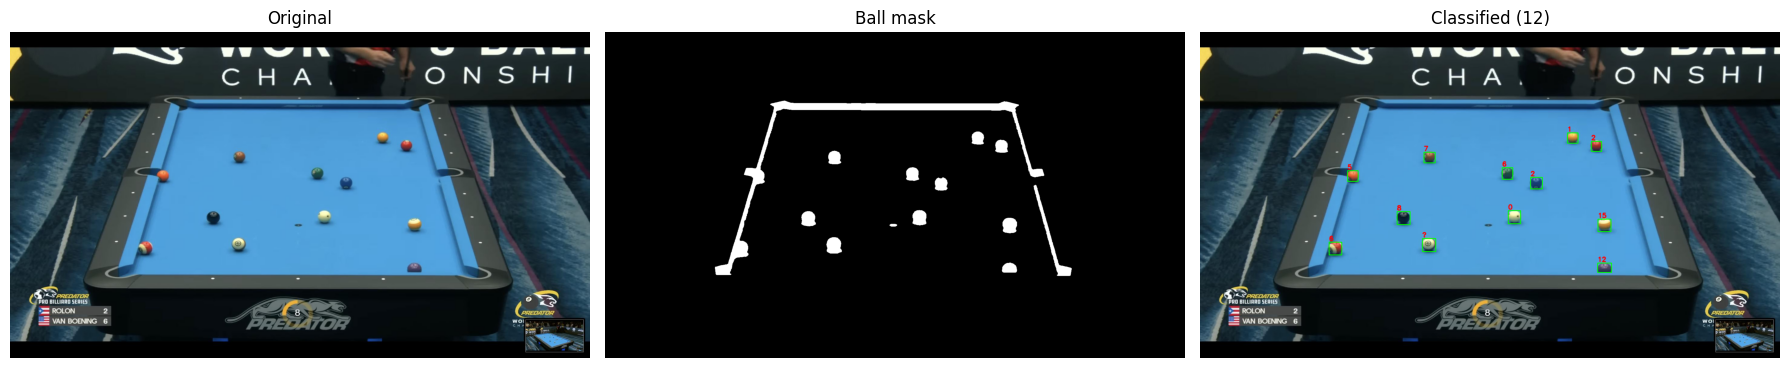

In [25]:
ball_mask_orig = get_ball_mask_original(bgr)
detections = extract_ball_bboxes_watershed(ball_mask_orig, bgr)

vis = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy()
for det in detections:
    ball_num = classify_ball(det, bgr, ball_mask_orig)
    x1, y1, x2, y2 = det['x1'], det['y1'], det['x2'], det['y2']

    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    label = str(ball_num) if ball_num is not None else "?"
    cv2.putText(vis, label, (x1, max(15, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2, cv2.LINE_AA)

print(f"Balls detected: {len(detections)}")
show_many(
    [cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), ball_mask_orig, vis],
    titles=["Original", "Ball mask", f"Classified ({len(detections)})"],
    cols=3,
    figsize=(18, 6)
)

### **DEBUG** Nao apagar por fa

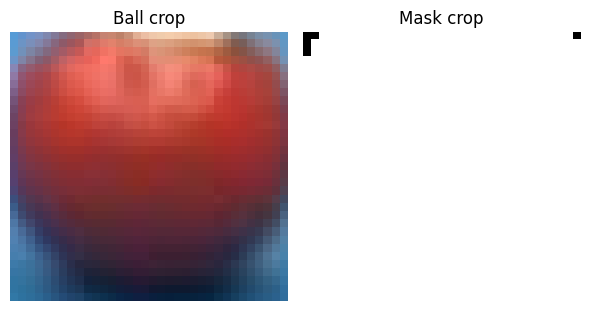

In [31]:
# Visualize the crop of a known stripe ball
det = detections[1]  # change to a known stripe
x1, y1, x2, y2 = det['x1'], det['y1'], det['x2'], det['y2']
ih, iw = bgr.shape[:2]
x1, y1 = max(0, x1), max(0, y1)
x2, y2 = min(iw, x2), min(ih, y2)

bgr_crop = bgr[y1:y2, x1:x2]
mask_crop = ball_mask_orig[y1:y2, x1:x2]

show_many(
    [cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2RGB), mask_crop],
    titles=["Ball crop", "Mask crop"],
    cols=2,
    figsize=(6, 4)
)

In [32]:
# Diagnostic — print median HSV for each detection
for i, det in enumerate(detections):
    x1, y1, x2, y2 = det['x1'], det['y1'], det['x2'], det['y2']
    ih, iw = bgr.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(iw, x2), min(ih, y2)

    bgr_crop = bgr[y1:y2, x1:x2]
    mask_crop = ball_mask_orig[y1:y2, x1:x2]
    hsv_crop = cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2HSV)

    white_frac = get_white_fraction(hsv_crop, mask_crop)
    median_hsv = get_dominant_colour(hsv_crop, mask_crop)
    ball_num = classify_ball(det, bgr, ball_mask_orig)

    print(f"Detection {i:2d}: median_hsv={median_hsv}, "
          f"white_frac={white_frac:.2f}, "
          f"classified={ball_num}")

Detection  0: median_hsv=(21, 149, 173), white_frac=0.07, classified=1
Detection  1: median_hsv=(105, 152, 140), white_frac=0.03, classified=2
Detection  2: median_hsv=(21, 112, 111), white_frac=0.03, classified=7
Detection  3: median_hsv=(90, 152, 92), white_frac=0.06, classified=6
Detection  4: median_hsv=(9, 160, 188), white_frac=0.03, classified=5
Detection  5: median_hsv=(106, 197, 120), white_frac=0.00, classified=2
Detection  6: median_hsv=(51, 71, 175), white_frac=0.66, classified=0
Detection  7: median_hsv=(102, 196, 65), white_frac=0.00, classified=8
Detection  8: median_hsv=(28, 124, 171), white_frac=0.27, classified=15
Detection  9: median_hsv=(54, 65, 151), white_frac=0.50, classified=None
Detection 10: median_hsv=(39, 134, 140), white_frac=0.14, classified=6
Detection 11: median_hsv=(117, 92, 111), white_frac=0.16, classified=12


[go back to top](###Dataset-Inspection)